<a href="https://colab.research.google.com/github/giumont/overlap_resolver/blob/main/notebooks/DNN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT FILE DATI DA GOOGLE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# IMPORT GITHUB REPO: flavour_tag_ml (repo "flavour_tagging")

from google.colab import userdata
import os
import sys

token = userdata.get("GITHUB_TOKEN")

REPO_PATH_FLAVOUR_TAG_ML = "/content/flavour_tagging"

if not os.path.exists(REPO_PATH_FLAVOUR_TAG_ML):
    !git clone https://{token}@github.com/giumont/flavour_tagging.git {REPO_PATH_FLAVOUR_TAG_ML}
else:
    !git -C {REPO_PATH_FLAVOUR_TAG_ML} pull --rebase

# The importable package lives under <repo>/src/flavour_tag_ml, so we add
# <repo>/src (not the repo root) to sys.path and import it as a top-level
# package: "import flavour_tag_ml".
SRC_PATH_FLAVOUR_TAG_ML = os.path.join(REPO_PATH_FLAVOUR_TAG_ML, "src")
if SRC_PATH_FLAVOUR_TAG_ML not in sys.path:
    sys.path.append(SRC_PATH_FLAVOUR_TAG_ML)

import flavour_tag_ml


remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 431 bytes | 143.00 KiB/s, done.
From https://github.com/giumont/flavour_tagging
   7034320..383f8cc  main       -> origin/main
Updating 7034320..383f8cc
Fast-forward
 src/flavour_tag_ml/graphics.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [ ]:
# IMPORT GITHUB REPO: overlap_resolver
#
# Contains, under "src/": obj_3_1.py, overlap_kinematics.py,
# truth_vs_reco_params.py and overlap_pairs_dataset_builder.py (this
# notebook's main orchestrator).

token_overlap = userdata.get("GITHUB_TOKEN_OVERLAP_RESOLVER")

REPO_PATH_OVERLAP_RESOLVER = "/content/overlap_resolver"

if not os.path.exists(REPO_PATH_OVERLAP_RESOLVER):
    !git clone https://{token_overlap}@github.com/giumont/overlap_resolver.git {REPO_PATH_OVERLAP_RESOLVER}
else:
    !git -C {REPO_PATH_OVERLAP_RESOLVER} pull --rebase

# Unlike flavour_tag_ml, the modules under overlap_resolver/src are FLAT:
# they import each other directly (e.g. overlap_kinematics.py does
# "from obj_3_1 import ..." and "from truth_vs_reco_params import ...",
# NOT "from src.obj_3_1 import ..."). To keep them working unmodified, we
# append the "src" folder ITSELF to sys.path (not the repo root), and
# import them below as flat top-level modules.
SRC_PATH_OVERLAP_RESOLVER = os.path.join(REPO_PATH_OVERLAP_RESOLVER, "src")
if SRC_PATH_OVERLAP_RESOLVER not in sys.path:
    sys.path.append(SRC_PATH_OVERLAP_RESOLVER)


Cloning into '/content/overlap_resolver'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 381 (delta 48), reused 52 (delta 23), pack-reused 291 (from 1)
Receiving objects: 100% (381/381), 659.89 MiB | 27.39 MiB/s, done.
Resolving deltas: 100% (67/67), done.
Updating files: 100% (276/276), done.


In [ ]:
# IMPORT FILE PROGETTO DA GITHUB

from flavour_tag_ml.data import JetDataset, build_jet_features, extract_balanced_subset, compute_feature_stats
from flavour_tag_ml.merge_datasets import merge_checkpoint_chunks, check_checkpoint_progress

from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import CategoricalFocalLoss, run_epoch, get_predictions, train_model, create_dataloaders

from flavour_tag_ml.utils import set_seed, load_mmap, save_run_outputs, build_metrics_report, run_evaluation_suite

In [ ]:
# To reload imported files if they have been modified during runtime

import importlib
import flavour_tag_ml.data
import flavour_tag_ml.models
import flavour_tag_ml.training
import flavour_tag_ml.graphics
import flavour_tag_ml.utils

importlib.reload(flavour_tag_ml.data)
importlib.reload(flavour_tag_ml.merge_datasets)
importlib.reload(flavour_tag_ml.models)
importlib.reload(flavour_tag_ml.training)
importlib.reload(flavour_tag_ml.graphics)
importlib.reload(flavour_tag_ml.utils)

#from flavour_tag_ml.utils import build_jet_features

<module 'flavour_tag_ml.utils' from '/content/flavour_tagging/src/flavour_tag_ml/utils.py'>

In [ ]:
# IMPORT PYTHON LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sposta file in memoria locale colab
#!cp /content/drive/MyDrive/obj_2/*.h5 /content/

In [ ]:
#################################################################
# GLOBAL PARAMS
#################################################################

# FILES
#DATASETS_DIR = '/content/' #gpu
INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/HH_bbtt" #cpu

TRAINSET_X_NAME = 'X_train_normalized.npy'
TRAINSET_Y_NAME = 'y_train_normalized.npy'

VALSET_X_NAME   = 'X_val_normalized.npy'
VALSET_Y_NAME   = 'y_val_normalized.npy'

TESTSET_X_NAME  = 'X_test_normalized.npy'
TESTSET_Y_NAME = 'y_test_normalized.npy'

#CHECK_LOAD_FILENAME = 'train_normalization_params.npz' # file with weights and feature_names (available for full, not reduced dataset)
CHECK_LOAD_FILENAME = "pair_feature_names.npz"

# DATASET
N_TRAIN = None
N_VAL   = None
N_TEST  = None

# OUTPUT_DIR = '/content/drive/MyDrive/flavour_tagging/obj_2/datas/np_arrays/MC23G_dataset'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR = None

SUB_TRAINSET_NAME = None
SUB_VALSET_NAME = None
SUB_TESTSET_NAME = None

# PROBLEM DEFINITION
NUM_CLASSES = 4 # FF=0, FT=1, TF=2, TT=3
CLASS_NAMES = ["FF", "FT", "TF", "TT"]  # ordine coerente con le label 0,1,2,3

TASK = "multiclass" if NUM_CLASSES > 2 else "binary"

# RETE
HIDDEN_DIMS = (32, 16)

ACTIV_FUNC = nn.ReLU()
NORM_LAYER = nn.LayerNorm

DROPOUT = 0.1 # percentuale neuroni disattivati randomicamente: riduce overfitting

MODEL_CONFIG = {
    "name": "MLPMultiTagger",
    "hidden_dims": HIDDEN_DIMS,
    "num_classes": NUM_CLASSES,
    "norm_layer": NORM_LAYER,
    "dropout": DROPOUT,
}

# TRAINING
BEST_MODEL_FOR_VALIDATION = True # False: salva a prescindere i weights dell'ultima epoca; True: previene overfitting
BEST_MODEL_METRIC = "ap_macro" # "mean" / "median" / "f1_macro" / "ap_macro": quale metrica su val viene considerata per aggiornare best_model

SAMPLING_STRATEGY = "none" # "none" / "oversample" / "undersample"

CRITERION = CategoricalFocalLoss()
WEIGHTED_LOSS = True

LR = 1e-3 # learning rate ottimizzatore
WEIGHT_DECAY = 1e-4  # regolarizzazione L2 nell'ottimizzatore

OPTIMIZER_CONFIG = {
    "name": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}

SCHEDULER_FACTOR = 0.7
SCHEDULER_PATIENCE = 5

SCHEDULER_CONFIG = {
    "name": "ReduceLROnPlateau",
    "factor": SCHEDULER_FACTOR,
    "patience": SCHEDULER_PATIENCE,
    "mode": "max"   # "max" must be used with "f1_macro" / "ap_macro" metrics
}

BATCH_SIZE = 2048
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

MIN_DELTA_VAL_LOSS = 1e-4 # soglia minima miglioramento loss su valset tra due epoche

# Suffisso comune per i nomi dei file salvati (architettura + training)
RUN_TAG = (
    f"{len(HIDDEN_DIMS)}layers_"
    f"{'_'.join(str(h) for h in HIDDEN_DIMS)}_"
    f"dropout{DROPOUT}_{NORM_LAYER.__name__}_batch{BATCH_SIZE}"
    f"_lr{LR}_wd{WEIGHT_DECAY}"
    f"_best_on_{BEST_MODEL_METRIC}"
    f"_criterion_{CRITERION}"
    f"_weight_loss_{WEIGHTED_LOSS}"
    f"_sampling_strategy_{SAMPLING_STRATEGY}"
)

# Store weights: nome/percorso generati automaticamente da RUN_TAG,
MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = f"best_model_{RUN_TAG}.pt"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

CHECKPOINT_NAME = f"checkpoint_{RUN_TAG}.pt"
CHECKPOINT_PATH = os.path.join(MODEL_DIR, CHECKPOINT_NAME)

# GRAPHICS
GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/HH_bbtt_dataset"
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# GITHUB
GIT_OUTPUT_DIR = "DNN/HH_bbtt_dataset"

# OTHER
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# SET GLOBAL SEED
set_seed(RANDOM_SEED)

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [ ]:
# LOADING INPUT

X_train = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(377567, 21) (377567,)
(80923, 21) (80923,)
(81083, 21) (81083,)


In [ ]:
# WEIGHTS PER LOSS PESATA - GESTIONE IMBALANCE CLASSI

if WEIGHTED_LOSS:
  # Class weighting per gestire l'imbalance (FF 10.1%, FT 73.1%, TF 16.1%, TT 0.65%).
  # Calcolati SOLO sul train set (mai su val/test).
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()
  CLASS_WEIGHTS = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
  CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)

  if isinstance(CRITERION, nn.CrossEntropyLoss):
    CRITERION.weight=CLASS_WEIGHTS
  elif isinstance(CRITERION, CategoricalFocalLoss):
    CRITERION.alpha=CLASS_WEIGHTS
  else:
    raise ValueError("The specified criterion is not available.")

else:
  CLASS_WEIGHTS = None

In [ ]:
# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI

PLOT_PARAMS = {
    "n_overlap_couples": int(X_train.shape[0]),
    "n_features": int(X_train.shape[1]),
    "class_names": CLASS_NAMES,
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "best_model_metric": BEST_MODEL_METRIC,
    "sampling_strategy": SAMPLING_STRATEGY,
    "criterion": CRITERION,
    "class_weights": CLASS_WEIGHTS,

}


In [ ]:
# Extraction of balanced subOUTPUT of required dimensions

X_train, y_train = extract_balanced_subset(X_train, y_train, N_TRAIN, seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TRAINSET_NAME)
X_val,   y_val   = extract_balanced_subset(X_val,   y_val,   N_VAL,   seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_VALSET_NAME)
X_test,  y_test  = extract_balanced_subset(X_test,  y_test,  N_TEST,  seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TESTSET_NAME)

print("Train:", X_train.shape, y_train.shape, "| bilanciamento:", y_train.mean())
print("Val:  ", X_val.shape,   y_val.shape,   "| bilanciamento:", y_val.mean())
print("Test: ", X_test.shape,  y_test.shape,  "| bilanciamento:", y_test.mean())

NameError: name 'X_train' is not defined

In [ ]:
# # CHECK - VERIFY RELOAD CORRECTNESS

# if CHECK_LOAD_FILENAME is None:
#     print("INFO - CHECK_LOAD_FILENAME non specificato: salto il caricamento dei parametri di normalizzazione e dei nomi features.")
#     mean = std = train_feature_names = None

# else:
#     norm_params_path = os.path.join(INPUT_DIR, CHECK_LOAD_FILENAME)

#     if os.path.exists(norm_params_path):
#         norm_params_npz = np.load(norm_params_path, allow_pickle=True)

#         print(f"Chiavi in {CHECK_LOAD_FILENAME}:", norm_params_npz.files)

#         mean = norm_params_npz['mean']
#         std = norm_params_npz['std']
#         train_feature_names = norm_params_npz['feature_names']

#         print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#         print("N. feature names:", len(train_feature_names))
#         print("Esempio:", train_feature_names[:3])

#     else:
#         print(f"INFO - '{norm_params_path}' non trovato: salto i controlli su mean/std/feature_names salvati.")
#         mean = std = train_feature_names = None


# print("\n=== SHAPES ===")
# print("X_train:", X_train.shape, "| y_train:", y_train.shape)
# print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
# print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

# # Coerenza numero campioni X <-> y, per ogni split
# assert len(X_train) == len(y_train), "Mismatch train X/y!"
# assert len(X_val) == len(y_val), "Mismatch val X/y!"
# assert len(X_test) == len(y_test), "Mismatch test X/y!"

# # Stessa dimensionalità delle feature in tutti gli split
# n_features = X_train.shape[1]
# assert X_val.shape[1] == n_features, "Val ha un numero di feature diverso dal train!"
# assert X_test.shape[1] == n_features, "Test ha un numero di feature diverso dal train!"

# if train_feature_names is not None:
#     print("\n=== FEATURE NAMES (da train_normalization_params.npz) ===")
#     print("N. nomi:", len(train_feature_names), "| N. colonne X:", n_features)
#     assert len(train_feature_names) == n_features, "feature_names non combacia col numero di colonne!"
#     print("Primi 3:", train_feature_names[:3])
#     print("Ultimi 3:", train_feature_names[-3:])

#     print("\n=== NORMALIZZAZIONE (mean/std salvati) ===")
#     print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#     assert mean.shape[0] == n_features and std.shape[0] == n_features, "mean/std non combaciano col numero di feature!"

# print("\n=== BILANCIAMENTO CLASSI ===")
# print("Train:", y_train.mean())
# print("Val:  ", y_val.mean())
# print("Test: ", y_test.mean())

# print("\n=== NaN / Inf SU CAMPIONE (evita di leggere l'intero memmap da disco) ===")
# sample_size = 200_000
# for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
#     n = min(sample_size, len(arr))
#     idx = np.sort(np.random.choice(len(arr), size=n, replace=False))
#     sample = arr[idx]
#     n_nan = np.isnan(sample).sum()
#     n_inf = np.isinf(sample).sum()
#     print(f"{name} (campione di {n}): NaN={n_nan}, Inf={n_inf}")
#     assert n_nan == 0 and n_inf == 0, f"{name} contiene NaN/Inf nel campione controllato!"

# print("\n=== SINGOLO CAMPIONE (X_train[0], y_train[0]) ===")
# x_sample, y_sample = X_train[0], y_train[0]
# print("Shape singolo campione X:", np.shape(x_sample), "| dtype:", np.asarray(x_sample).dtype)
# print("Shape singolo campione y:", np.shape(y_sample), "| dtype:", np.asarray(y_sample).dtype)

# print("\nTutti i controlli superati (su campionamento per gli split memory-mapped).")

# # Mean and std on datasets
# mean_train, std_train = compute_feature_stats(X_train)
# mean_val,   std_val   = compute_feature_stats(X_val)
# mean_test,  std_test  = compute_feature_stats(X_test)


# print("\n================ NORMALIZATION CHECK ================\n")

# print("TRAIN")
# print(f"  mean range: [{mean_train.min():.6f}, {mean_train.max():.6f}]")
# print(f"  std  range: [{std_train.min():.6f}, {std_train.max():.6f}]")

# print("\nVAL")
# print(f"  mean range: [{mean_val.min():.6f}, {mean_val.max():.6f}]")
# print(f"  std  range: [{std_val.min():.6f}, {std_val.max():.6f}]")

# print("\nTEST")
# print(f"  mean range: [{mean_test.min():.6f}, {mean_test.max():.6f}]")
# print(f"  std  range: [{std_test.min():.6f}, {std_test.max():.6f}]")

Chiavi in pair_feature_names.npz: ['feature_names', 'label_index_map', 'dr_thr']


KeyError: 'mean is not a file in the archive'

In [ ]:
# Dataset Pytorch

train_dataset = JetDataset(X_train, y_train, task=TASK)
val_dataset = JetDataset(X_val, y_val, task=TASK)
test_dataset = JetDataset(X_test, y_test, task=TASK)

# Check type is matched with the type of loss function used
assert train_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(train_dataset.y).tolist()) <= set(range(NUM_CLASSES))

In [ ]:
# DataLoader pytorch — ora tramite create_dataloaders, che espone
# sampling_strategy ("none" / "oversample" / "undersample") invece
# dello shuffle=True fisso di prima.
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,
    sampling_strategy=SAMPLING_STRATEGY,
    num_workers=2,
)


In [ ]:
# Modello
model = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])

# Optimizer e scheduler creati internamente da train_model a partire
# dai config dict (OPTIMIZER_CONFIG, SCHEDULER_CONFIG)
model, train_losses, val_losses = train_model(
    train_loader,
    val_loader,
    model,
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    criterion=CRITERION,
    max_epochs=MAX_EPOCHS,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    best_model_for_validation=BEST_MODEL_FOR_VALIDATION,
    model_selection_metric=BEST_MODEL_METRIC,
    model_path=MODEL_PATH,
    device=DEVICE,
    reset_weights=True,
    checkpoint_path=CHECKPOINT_PATH,
    resume_from_checkpoint=False,
)

INFO - Total number of trainable parameters: 1396
INFO - Model selection metric: 'ap_macro'


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.4381 | Val Loss (mean): 0.3002 | Val F1 (macro): 0.6327 | Val AP (macro): 0.6753


...

Epoch 26/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 26/50 | Train Loss: 0.2400 | Val Loss (mean): 0.2385 | Val F1 (macro): 0.6635 | Val AP (macro): 0.7100


Epoch 27/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 27/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 27/50 | Train Loss: 0.2388 | Val Loss (mean): 0.2391 | Val F1 (macro): 0.6534 | Val AP (macro): 0.7093
Early stopping.


In [ ]:
# import shutil, os, time

# LOCAL_PATH = '/content/local_data'
# os.makedirs(LOCAL_PATH, exist_ok=True)

# files_to_copy = [
#     'X_train_normalized.npy', 'y_train_normalized.npy',
#     'X_val_normalized.npy',   'y_val_normalized.npy',
# ]

# for f in files_to_copy:
#     src = os.path.join(DATASETS_DIR, f)
#     dst = os.path.join(LOCAL_PATH, f)
#     if not os.path.exists(dst):
#         t0 = time.time()
#         shutil.copy(src, dst)
#         print(f"{f}: copiato in {time.time()-t0:.1f}s")
#     else:
#         print(f"{f}: già presente")

In [ ]:
# def load_mmap_local(name):
#     return np.load(os.path.join(LOCAL_PATH, name), mmap_mode='r')

# X_train = load_mmap_local('X_train_normalized.npy')
# y_train = load_mmap_local('y_train_normalized.npy')
# X_val   = load_mmap_local('X_val_normalized.npy')
# y_val   = load_mmap_local('y_val_normalized.npy')

# train_dataset_partial = JetDataset(X_train, y_train)
# val_dataset_partial   = JetDataset(X_val, y_val)

In [ ]:
# import time
# t0 = time.time()
# for i, (xb, yb) in enumerate(train_loader):
#     if i == 50:
#         break
# t1 = time.time()
# print(f"Tempo per 50 step: {t1-t0:.1f}s -> stima per epoca: {(t1-t0)/50 * len(train_loader):.1f}s")

In [ ]:
#################################################################
# VALUTAZIONE MODELLO + SALVATAGGIO OUTPUT (FIGURE + CONFIG + DATI) SULLA REPO GITHUB
#################################################################
ATLAS_STYLE = True                          # oppure False se non hai mplhep installato
BACKGROUND_REJECTION_EFF_RANGE = (0.2, 1.0) # range realistico per il plot principale
WORKING_POINT_TARGETS = (0.70, 0.75, 0.80, 0.85, 0.90, 0.97)

config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "output_dir": OUTPUT_DIR,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "sub_trainset_name": SUB_TRAINSET_NAME,
        "sub_valset_name": SUB_VALSET_NAME,
        "sub_testset_name": SUB_TESTSET_NAME,
        "n_overlap_couples": int(X_train.shape[0]),
        "n_features": int(X_train.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
    },
    "training": {
        "criterion": CRITERION.__class__.__name__,
        "class_weights": CLASS_WEIGHTS,
        "optimizer": OPTIMIZER_CONFIG,
        "scheduler": SCHEDULER_CONFIG,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_delta_val_loss": MIN_DELTA_VAL_LOSS,
        "best_model_for_validation": BEST_MODEL_FOR_VALIDATION,
        "sampling_strategy": SAMPLING_STRATEGY,
        "model_selection_metric": BEST_MODEL_METRIC,
        "seed": RANDOM_SEED,
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        # tracciati per riproducibilita' delle scelte di plotting
        "atlas_style": ATLAS_STYLE,
        "background_rejection_eff_range": BACKGROUND_REJECTION_EFF_RANGE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


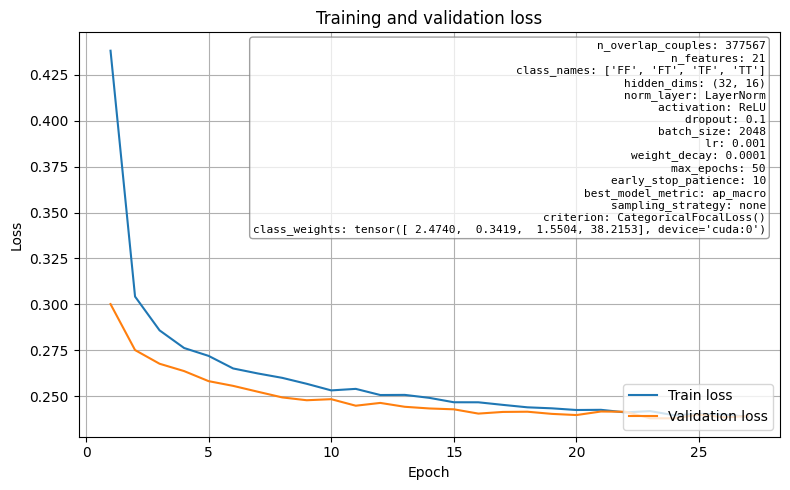

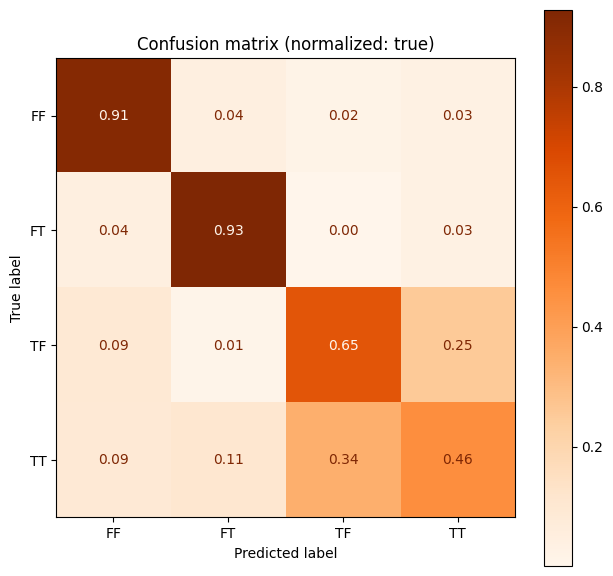

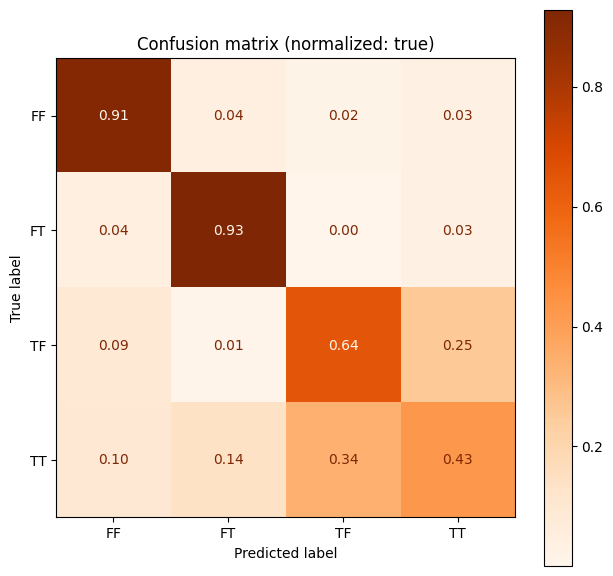

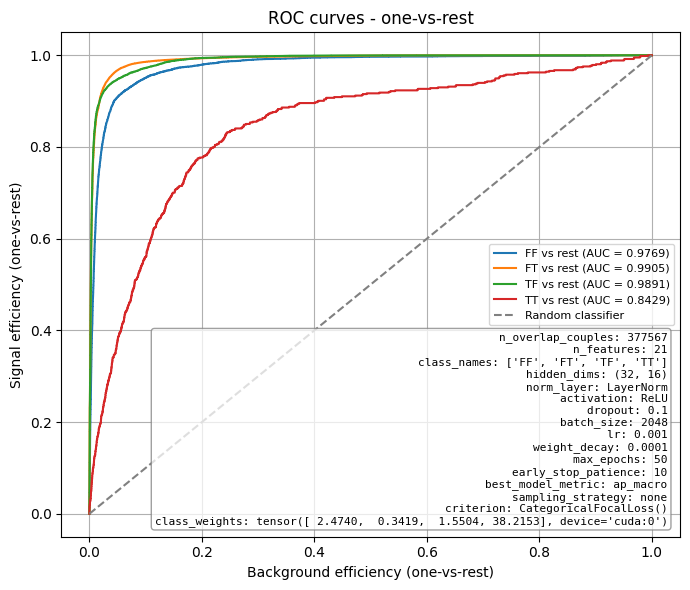

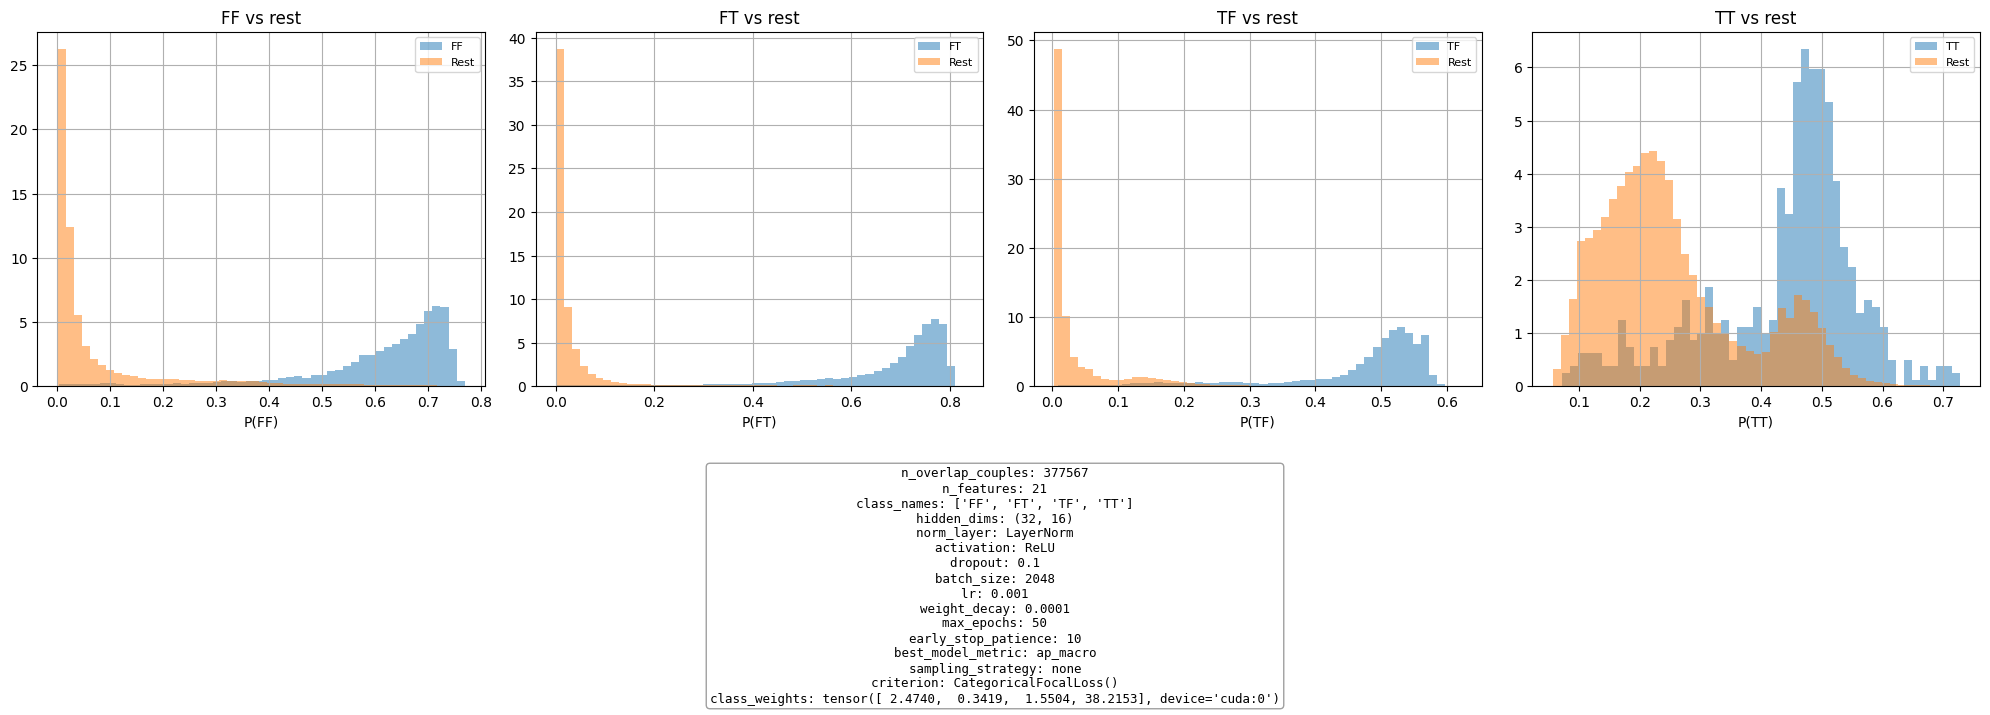

RUN METRICS REPORT - 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
run_tag: 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
timestamp: 2026-09-23T12:13:39

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7312 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  class_weights: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:

In [ ]:
eval_result = run_evaluation_suite(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    train_losses=train_losses,
    val_losses=val_losses,
    device=DEVICE,
    config=config,
    params=PLOT_PARAMS,
    run_name=RUN_TAG,
    run_tag=RUN_TAG,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    class_names=CLASS_NAMES,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    background_rejection_eff_range=BACKGROUND_REJECTION_EFF_RANGE,
    checkpoint_path=CHECKPOINT_PATH,
)

result = eval_result["push_result"]